In [1]:
#pip install pandas numpy matplotlib jupyter

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
deliveries = pd.read_csv("../data/deliveries.csv")
drivers = pd.read_csv("../data/drivers.csv")
vehicles = pd.read_csv("../data/vehicles.csv")
hubs = pd.read_csv("../data/hubs.csv")
complaints = pd.read_csv("../data/complaints.csv")
incidents = pd.read_csv("../data/incidents.csv")
app_events = pd.read_csv("../data/app_events.csv")
data_dictionary = pd.read_csv("../data/data_dictionary.csv")

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, df.shape)

customers (650, 9)
orders (1250, 11)
deliveries (950, 13)
drivers (170, 8)
vehicles (120, 8)
hubs (8, 5)
complaints (320, 10)
incidents (280, 7)
app_events (640, 10)


In [5]:
customers.head()
orders.head()
deliveries.head()
drivers.head()
vehicles.head()
hubs.head()
complaints.head()
incidents.head()
app_events.head()

,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1
3,AE00004,C0407,O00756,2025-08-23 17:38:00,eta_refresh,S41236,iOS,CENTRAL,442,1
4,AE00005,C0506,NaN,2024-05-29 10:33:00,search_route,S12030,iOS,north,60,1


In [6]:
for name, df in datasets.items():
    print("\n===================")
    print(name)
    print(df.columns.tolist())


customers
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

orders
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

deliveries
['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost']

drivers
['driver_id', 'base_zone', 'employment_type', 'years_experience', 'training_score', 'driver_rating', 'shift_preference', 'active_flag']

vehicles
['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date', 'battery_health_pct', 'odometer_km', 'maintenance_status', 'telematics_version']

hubs
['hub_id', 'hub_name', 'zone', 'hub_type', 'capaci

In [7]:
for name, df in datasets.items():
    print("\n===================")
    print(name)
    print(df.isnull().sum())


customers
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64

orders
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

deliveries
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing     

In [8]:
for name, df in datasets.items():
    print(name, "duplicates:", df.duplicated().sum())

customers duplicates: 0
orders duplicates: 0
deliveries duplicates: 0
drivers duplicates: 0
vehicles duplicates: 0
hubs duplicates: 0
complaints duplicates: 0
incidents duplicates: 0
app_events duplicates: 0


In [9]:
deliveries["delivery_status"].unique()

array(['Failed', 'OnTime', 'Delayed'], dtype=object)

In [10]:
orders["service_type"].unique()
complaints["severity"].unique()
vehicles["maintenance_status"].unique()

array(['Active', 'InRepair', 'Scheduled'], dtype=object)

In [11]:
deliveries["delivery_status"].value_counts()

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

In [12]:
complaints["complaint_type"].value_counts()

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64

In [13]:
incidents["incident_type"].value_counts()

incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64

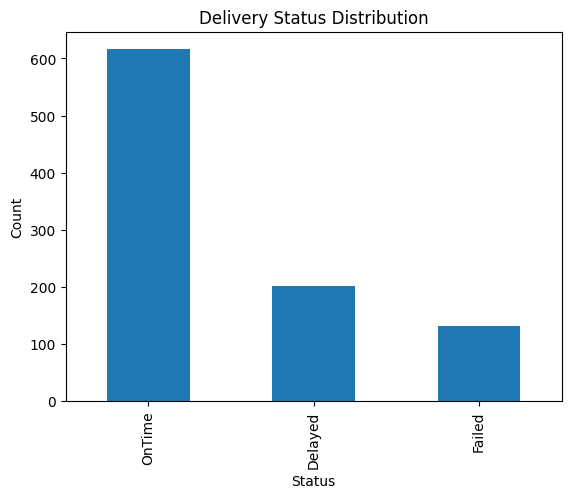

In [14]:
deliveries["delivery_status"].value_counts().plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

In [15]:
delivery_analysis = (
    deliveries
    .merge(orders, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(drivers, on="driver_id", how="left")
    .merge(vehicles, on="vehicle_id", how="left")
    .merge(hubs, on="hub_id", how="left")
)

In [16]:
delivery_analysis.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,CENTRAL,2024-06-09 16:18:00,78.4,29849,Active,v2.2,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,AIRPORT,2025-09-17 08:52:00,68.6,78468,Active,v2.2,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,Riverside,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0,North Exchange,North,Dispatch,82
